### Imports

In [1]:
from datetime import date
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Define timeframe for stock data (5 years)

In [2]:
end = date.today()
start = end.replace(
    year=end.year - 5,
    day = min(end.day, 28) if end.month == 2 else end.day
)

start_date = start.strftime("%Y-%m-%d")
end_date = end.strftime("%Y-%m-%d")

### Fetch and clean stock data

In [3]:
def get_stock_data(ticker):
    data = yf.download(ticker, start_date, end_date)
    return data

df = get_stock_data("AAPL")
df.reset_index(inplace=True)
df.columns = df.columns.get_level_values(0)
df.columns.name = None
df.head()

[*********************100%***********************]  1 of 1 completed


,Date,Close,High,Low,Open,Volume
0,2021-03-24,116.967125,119.704058,116.947648,119.626136,88530500
1,2021-03-25,117.454124,118.496307,115.905475,116.431434,98844700
2,2021-03-26,118.057991,118.320974,115.827540,117.220354,94071200
3,2021-03-29,118.233322,119.392379,117.590489,118.486563,80819200
4,2021-03-30,116.782082,117.269079,115.769125,116.986620,85671900


### Plot stock data

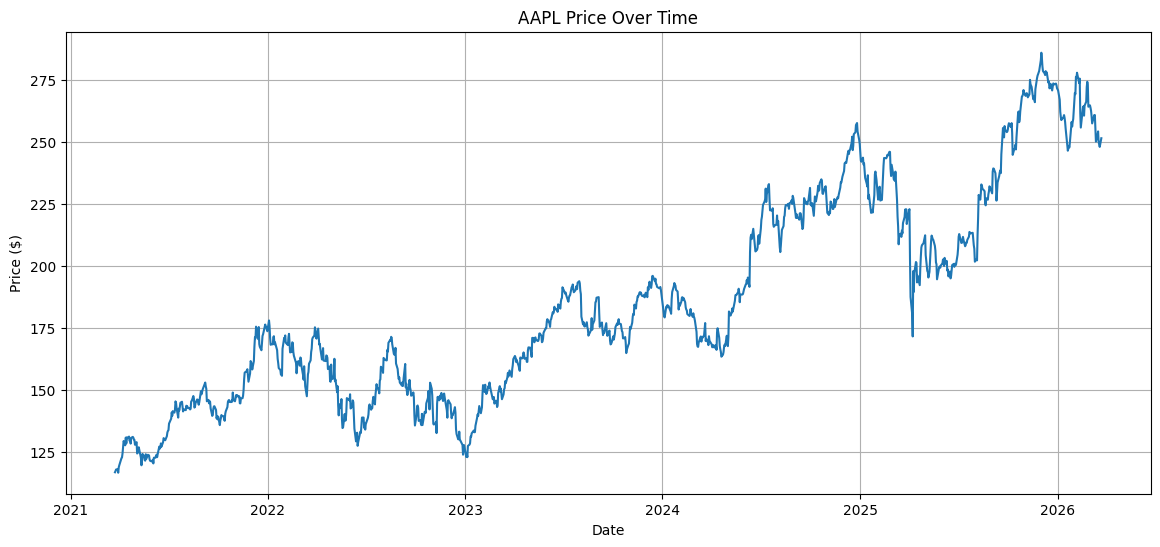

In [4]:
plt.figure(figsize=(14, 6))
plt.grid(True)
plt.plot(df["Date"], df["Close"])
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.title("AAPL Price Over Time")
plt.show()

### Plot the 9, 21, and 100 EMAs

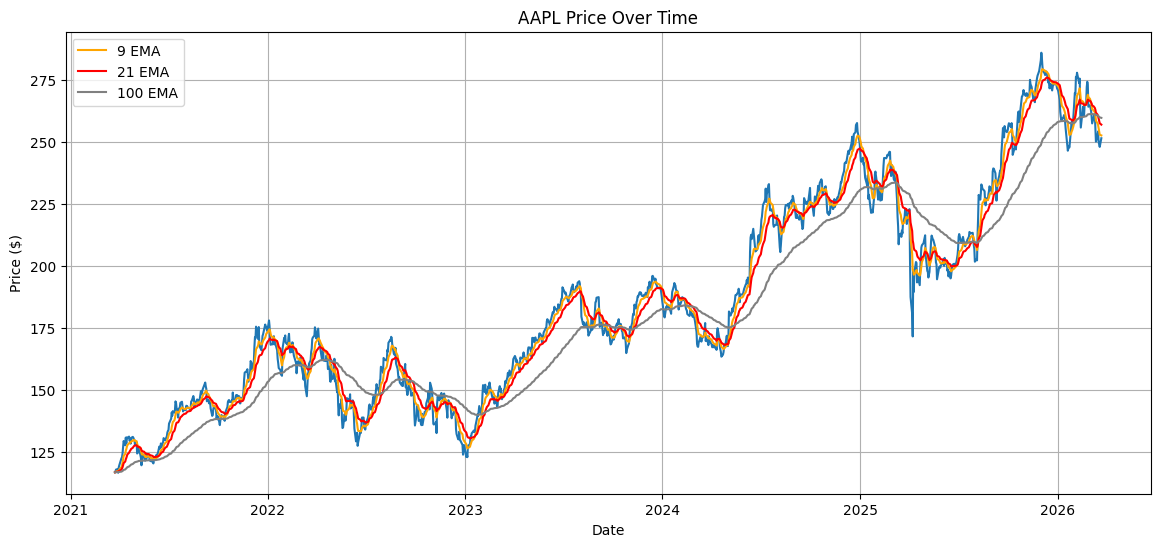

In [5]:
# Calculate EMAs
df["ema9"] = df["Close"].ewm(span=9, adjust=False).mean()
df["ema21"] = df["Close"].ewm(span=21, adjust=False).mean()
df["ema100"] = df["Close"].ewm(span=100, adjust=False).mean()

# Plot price
plt.figure(figsize=(14, 6))
plt.grid(True)
plt.plot(df["Date"], df["Close"])
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.title("AAPL Price Over Time")

# Plot EMAs
plt.plot(df["Date"], df["ema9"], label="9 EMA", color="orange")
plt.plot(df["Date"], df["ema21"], label="21 EMA", color="red")
plt.plot(df["Date"], df["ema100"], label="100 EMA", color="gray")
plt.legend()

### Create 21 EMA distance, 21 EMA slope, and price return features

In [6]:
df["dist_ema21"] = (df["Close"] - df["ema21"]) / df["ema21"]
df["slope_ema21"] = df["ema21"].diff()
df["return"] = df["Close"].pct_change()
df.head()

,Date,Close,High,Low,Open,Volume,ema9,ema21,ema100,dist_ema21,slope_ema21,return
0,2021-03-24,116.967125,119.704058,116.947648,119.626136,88530500,116.967125,116.967125,116.967125,0.000000,NaN,NaN
1,2021-03-25,117.454124,118.496307,115.905475,116.431434,98844700,117.064525,117.011398,116.976768,0.003784,0.044273,0.004164
2,2021-03-26,118.057991,118.320974,115.827540,117.220354,94071200,117.263218,117.106542,116.998179,0.008125,0.095145,0.005141
3,2021-03-29,118.233322,119.392379,117.590489,118.486563,80819200,117.457239,117.208977,117.022637,0.008739,0.102435,0.001485
4,2021-03-30,116.782082,117.269079,115.769125,116.986620,85671900,117.322207,117.170168,117.017874,-0.003312,-0.038809,-0.012274


In [7]:
df = df.dropna().reset_index(drop=True)
df.drop(columns=["High", "Low", "Open", "Volume"], inplace=True)
df.head()

,Date,Close,ema9,ema21,ema100,dist_ema21,slope_ema21,return
0,2021-03-25,117.454124,117.064525,117.011398,116.976768,0.003784,0.044273,0.004164
1,2021-03-26,118.057991,117.263218,117.106542,116.998179,0.008125,0.095145,0.005141
2,2021-03-29,118.233322,117.457239,117.208977,117.022637,0.008739,0.102435,0.001485
3,2021-03-30,116.782082,117.322207,117.170168,117.017874,-0.003312,-0.038809,-0.012274
4,2021-03-31,118.973572,117.652480,117.334114,117.056600,0.013973,0.163946,0.018766


### Use a 70/30 train/test split

In [8]:
df.shape

(1254, 8)

In [9]:
split = int(len(df) * 0.7)
train = df[:split]
test = df[split:]

In [10]:
print(train.shape)
train.head()

(877, 8)


,Date,Close,ema9,ema21,ema100,dist_ema21,slope_ema21,return
0,2021-03-25,117.454124,117.064525,117.011398,116.976768,0.003784,0.044273,0.004164
1,2021-03-26,118.057991,117.263218,117.106542,116.998179,0.008125,0.095145,0.005141
2,2021-03-29,118.233322,117.457239,117.208977,117.022637,0.008739,0.102435,0.001485
3,2021-03-30,116.782082,117.322207,117.170168,117.017874,-0.003312,-0.038809,-0.012274
4,2021-03-31,118.973572,117.652480,117.334114,117.056600,0.013973,0.163946,0.018766


In [11]:
print(test.shape)
test.head()

(377, 8)


,Date,Close,ema9,ema21,ema100,dist_ema21,slope_ema21,return
877,2024-09-19,227.376389,220.716984,220.844810,210.221920,0.029575,0.653158,0.037066
878,2024-09-20,226.710754,221.915738,221.378078,210.548432,0.024089,0.533268,-0.002927
879,2024-09-23,224.992035,222.530998,221.706619,210.834443,0.014819,0.328542,-0.007581
880,2024-09-24,225.886154,223.202029,222.086577,211.132497,0.017109,0.379958,0.003974
881,2024-09-25,224.892700,223.540163,222.341679,211.404976,0.011473,0.255102,-0.004398


### Normalize the dataset

In [12]:
from sklearn.preprocessing import MinMaxScaler

In [13]:
# MinMaxScaler has default param feature_range=(0,1)
scaler = MinMaxScaler()

features = ["Close", "ema21", "dist_ema21", "slope_ema21", "return"]

train_features = train[features]
test_features = test[features]

# Scale training data
train_features_scaled = scaler.fit_transform(train_features)

# Scale testing data
prev_20_features = train_features.tail(20)
test_features = pd.concat([prev_20_features, test_features], ignore_index=True)
test_features_scaled = scaler.transform(test_features)

print(train_features_scaled.shape)
print(test_features_scaled.shape)

(877, 5)
(397, 5)


In [14]:
print(train_features_scaled[:5])
print(train_features_scaled[-5:])

[[0.00578172 0.         0.516152   0.4529993  0.42560977]
 [0.01097691 0.0009001  0.53779525 0.46770436 0.43223158]
 [0.01248532 0.00186917 0.54086068 0.4698115  0.40746988]
 [0.         0.00150202 0.48077417 0.42898388 0.31428254]
 [0.01885384 0.00305301 0.56695153 0.48759188 0.5245035 ]]
[[0.89932822 0.98750687 0.49550493 0.43791342 0.40075715]
 [0.89702081 0.98720812 0.49017521 0.43107358 0.38920434]
 [0.8441999  0.98165622 0.36475831 0.27056437 0.20930117]
 [0.84821676 0.97701059 0.38614466 0.2982553  0.41212565]
 [0.88155038 0.97611952 0.47596064 0.41297552 0.51924911]]


In [15]:
print(test_features_scaled[:5])
print(test_features_scaled[-5:])

[[0.93035416 0.96898792 0.62190315 0.59874184 0.39412228]
 [0.91437136 0.97210718 0.57208966 0.53551038 0.34147286]
 [0.93411491 0.97691656 0.61235366 0.58715175 0.46708854]
 [0.9370208  0.98157921 0.60859417 0.58266858 0.40756247]
 [0.9442858  0.98654424 0.61553137 0.59190765 0.4227515 ]]
[[1.18249254 1.35618849 0.37977692 0.26281595 0.43518271]
 [1.14558485 1.34722124 0.31511565 0.1662091  0.28312814]
 [1.13715374 1.33822638 0.3138823  0.16536511 0.37085697]
 [1.12880863 1.329215   0.3128659  0.16486049 0.37102433]
 [1.15891984 1.32403294 0.3910086  0.28186486 0.49299634]]


### Create training sequences

In [16]:
x_train = []
y_train = []

# For each timestamp (row) x, grab the 20 timestamps before it and add them as a singular element to x_train. Add timestamp x as an element to y_train.
for i in range(20, train_features_scaled.shape[0]):
    x_train.append(train_features_scaled[i - 20 : i])
    y_train.append(train_features_scaled[i, 0])

x_train = np.array(x_train)
y_train = np.array(y_train)

print(x_train.shape)
print(y_train.shape)

(857, 20, 5)
(857,)


### Create testing sequences

In [17]:
x_test = []
y_test = []

for i in range(20, test_features_scaled.shape[0]):
    x_test.append(test_features_scaled[i - 20 : i])
    y_test.append(test_features_scaled[i, 0])

x_test = np.array(x_test)
y_test = np.array(y_test)

print(x_test.shape)
print(y_test.shape)

(377, 20, 5)
(377,)


### Build LSTM model

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense

In [19]:
model = Sequential()

model.add(Input(shape=(x_train.shape[1], x_train.shape[2])))

model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(units=60, return_sequences=True))
model.add(Dropout(0.3))

model.add(LSTM(units=80, return_sequences=True))
model.add(Dropout(0.4))

model.add(LSTM(units=120))
model.add(Dropout(0.5))

model.add(Dense(units=1))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 50)         │        11,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 20, 60)         │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20, 60)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 20, 80)         │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 20, 80)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 179,561 (701.41 KB)

 Trainable params: 179,561 (701.41 KB)

 Non-trainable params: 0 (0.00 B)

### Train model

In [20]:
import tensorflow as tf

In [21]:
model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=[tf.keras.metrics.MeanAbsoluteError()]
)

model.fit(x_train, y_train, epochs=100)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0382 - mean_absolute_error: 0.1429
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0112 - mean_absolute_error: 0.0828
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0088 - mean_absolute_error: 0.0726
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0078 - mean_absolute_error: 0.0681
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0084 - mean_absolute_error: 0.0704
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0081 - mean_absolute_error: 0.0707
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0083 - mean_absolute_error: 0.0697
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0081 - mean_absolute_error: 0.0699
Epoch 9/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0064 - mean_absolute_error: 0.0615
Epoch 10/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0060 - mean_absolute_error: 0.0599
Epoch 11/100
27/27 ━━━━━━━━━━

### Make prediction

In [22]:
y_pred = model.predict(x_test)
print(y_pred.shape)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
(377, 1)


In [23]:
print(y_test[:10])

[0.95146546 0.94573887 0.93095238 0.93864467 0.93009778 0.93992696
 0.9422345  0.98676491 0.92873043 0.93360215]


In [24]:
print(y_pred[:10])

[[0.8800849 ]
 [0.93988264]
 [0.93432564]
 [0.9237492 ]
 [0.92915744]
 [0.9232688 ]
 [0.9319274 ]
 [0.93475217]
 [0.97215754]
 [0.92677647]]


### Plot prediction

In [25]:
# inverse_transform() now expects shape of (n_samples, 5), but y_pred has shape (n_samples, 1)
# solution: make dummy np arrays of shape (n_samples, 5)
dummy_pred = np.zeros((len(y_pred), 5))
dummy_test = np.zeros((len(y_test), 5))

dummy_pred[:, 0] = y_pred.flatten()
dummy_test[:, 0] = y_test

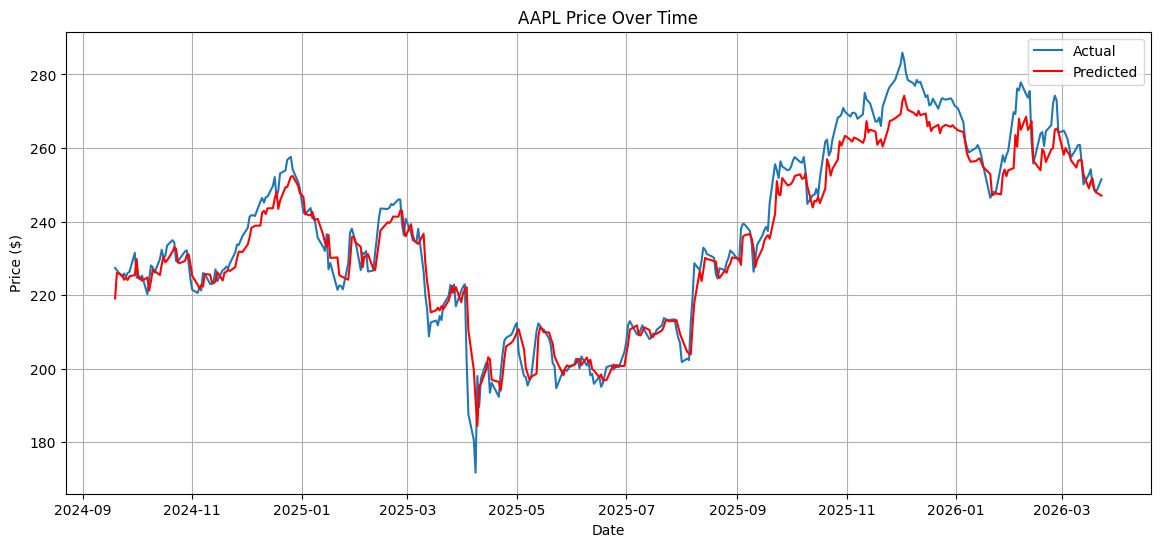

In [26]:
y_pred_prices = scaler.inverse_transform(dummy_pred)[:, 0]
y_test_prices = scaler.inverse_transform(dummy_test)[:, 0]

# Plot price
plt.figure(figsize=(14, 6))
plt.grid(True)
plt.plot(test["Date"], y_test_prices, label="Actual")
plt.plot(test["Date"], y_pred_prices, label="Predicted", color="red")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.title("AAPL Price Over Time")
plt.legend()